# Cybercrime in Germany: Cases, Clearance Rate and Differences Between the Federal States

### Police Crime Statistics (PKS) of the Federal Criminal Police Office (BKA), 2016 to 2025

This project analyses how recorded cybercrime in Germany developed over ten years. It uses only official, public data: the Police Crime Statistics (Polizeiliche Kriminalstatistik, PKS) published by the Federal Criminal Police Office (Bundeskriminalamt, BKA).

Three questions are answered:

1. **Cases:** how did the number of recorded cybercrime cases develop from 2016 to 2025?
2. **Clearance rate:** how did the clearance rate of cybercrime develop in the same period, compared with all recorded crime?
3. **Federal states:** how do the 16 federal states differ in cases per 100,000 inhabitants in 2025, and how did each state change since 2016?

Which offences count as cybercrime is not defined in this project. The definition of the BKA is used (aggregate key 897000, see Section 6).

Python is used for loading, checking, analysis and charts.

| Area | Scope |
|---|---|
| Subject | Cybercrime as defined by the BKA: aggregate key 897000 with its four offence keys 543000, 674200, 678000 and 897100 |
| Period | 2016 to 2025 at federal level; 2016 and 2025 for the federal states |
| Federal data | PKS 2025, time series of table T01 (cases, clearance rate), one row per offence key and year |
| State data | PKS 2016 and PKS 2025, table T01 for the federal states, one row per offence key and state |
| Measures | Recorded cases, clearance rate in %, cases per 100,000 inhabitants |
| Output | Two clean tables in `data/clean/`, three charts in `figures/` |

German terms of the PKS used in this notebook:

| German term | Term in this notebook |
|---|---|
| Erfasste Fälle | Recorded cases |
| Aufklärungsquote (AQ) | Clearance rate: cleared cases as a share of recorded cases |
| Häufigkeitszahl (HZ) | Cases per 100,000 inhabitants |
| Straftatenschlüssel | Offence key |
| Summenschlüssel | Aggregate key (sum of several offence keys) |
| Straftaten insgesamt | All recorded crime |

## 1. Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 2. Define Parameters and File Paths

The folder `data/raw` is searched upwards from the notebook folder, so the notebook runs from any subfolder of the project.

The analysis starts in 2016. The offence key 897100 (computer fraud) was introduced in that year, and the BKA marks the cybercrime figures of 2016 as not comparable with 2015 (see Section 6).

In [2]:
# Locate data/raw by walking up from the notebook folder
start = Path.cwd()
DATA_RAW = next(p / "data" / "raw" for p in [start, *start.parents] if (p / "data" / "raw").exists())
DATA_CLEAN = DATA_RAW.parent / "clean"
FIGURES = DATA_RAW.parent.parent / "figures"
DATA_CLEAN.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

FEDERAL_XLSX = DATA_RAW / "T01-ZR-Bund-Fälle_xls.xlsx"                 # PKS 2025, time series
STATES_2016_XLSX = DATA_RAW / "BKA-LKS-F-01-T01-Laender_excel.xlsx"    # PKS 2016, federal states
STATES_2025_XLSX = DATA_RAW / "LA-F-02-T01-Laender-Faelle-HZ_xls.xlsx" # PKS 2025, federal states

FIRST_YEAR, LAST_YEAR = 2016, 2025

# Offence keys of the PKS
KEY_ALL_CRIME = "------"                                    # all recorded crime
KEY_CYBER = "897000"                                        # aggregate key "Cybercrime"
CYBER_PARTS = ["543000", "674200", "678000", "897100"]      # its four offence keys since 2021
PIRACY_KEYS = ["715100", "715200"]                          # software piracy, part of 897000 until 2020

# English names of the federal states (states missing here have the same name in both languages)
STATE_NAMES_EN = {
    "Bayern": "Bavaria", "Hessen": "Hesse", "Mecklenburg-Vorpommern": "Mecklenburg-Western Pomerania",
    "Niedersachsen": "Lower Saxony", "Nordrhein-Westfalen": "North Rhine-Westphalia",
    "Rheinland-Pfalz": "Rhineland-Palatinate", "Sachsen": "Saxony", "Sachsen-Anhalt": "Saxony-Anhalt",
    "Thüringen": "Thuringia",
}

# Name of the national total row in the state tables
TOTAL_ROW_2016 = "Bund echte Zählung der Tatverdächtigen"
TOTAL_ROW_2025 = "Bundesrepublik Deutschland"

# Chart style
BLUE, MUTED = "#1f5a94", "#8a8a8a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

## 3. Load the Data

Three Excel files are loaded. Each file has several title and note rows above the data and a header that spans two rows, so the header is skipped and the column names are set by hand.

The offence key is read as text. Otherwise keys such as `010000` lose the leading zero, and the key of all recorded crime (`------`) cannot be read as a number at all.

| Column | Meaning |
|---|---|
| `key`, `offence` | Offence key and its German name |
| `year` / `state` | Reporting year (federal table) or federal state (state tables) |
| `cases` | Recorded cases |
| `rate` | Cases per 100,000 inhabitants (Häufigkeitszahl) |
| `cleared` | Cleared cases (state tables only) |
| `clearance_rate` | Clearance rate in % |

In [3]:
# Federal time series from 1987, one row per offence key and year ("-" marks a rate that cannot be given)
cols_federal = ["key", "offence", "year", "cases", "rate", "attempts", "attempts_pct",
                "firearm_threatened", "firearm_fired", "clearance_rate",
                "suspects", "suspects_non_german", "suspects_non_german_pct"]
federal = pd.read_excel(FEDERAL_XLSX, skiprows=15, header=None, names=cols_federal,
                        dtype={"key": str}, na_values="-")

# Federal states 2016 (this file has an extra column with the state code)
cols_2016 = ["key", "offence", "state_code", "state", "cases", "rate", "attempts", "attempts_pct",
             "cleared", "clearance_rate", "suspects", "suspects_non_german", "suspects_non_german_pct"]
states_2016 = pd.read_excel(STATES_2016_XLSX, skiprows=7, header=None, names=cols_2016,
                            dtype={"key": str, "state_code": str})

# Federal states 2025
cols_2025 = ["key", "offence", "state", "cases", "rate", "attempts", "attempts_pct",
             "cleared", "clearance_rate", "suspects", "suspects_non_german", "suspects_non_german_pct"]
states_2025 = pd.read_excel(STATES_2025_XLSX, skiprows=7, header=None, names=cols_2025,
                            dtype={"key": str})

tables = {"federal": federal, "states_2016": states_2016, "states_2025": states_2025}
for name, df in tables.items():
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]} columns")

federal: 14,995 rows, 13 columns
states_2016: 17,884 rows, 13 columns
states_2025: 19,431 rows, 12 columns


## 4. Check Data Quality

The general check covers table size, missing values, duplicate rows and text in number columns.

In [4]:
# One summary row per table
quality = pd.DataFrame({
    name: {
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        # values that are present but cannot be read as a number
        "non_numeric_values": int(sum(
            (pd.to_numeric(df[c], errors="coerce").isna() & df[c].notna()).sum()
            for c in ["cases", "rate", "clearance_rate"])),
    }
    for name, df in tables.items()
}).T
quality

,rows,columns,missing_values,duplicate_rows,non_numeric_values
federal,14995,13,11,0,0
states_2016,17884,13,0,0,0
states_2025,19431,12,0,0,0


In [5]:
# Where are the missing values?
for name, df in tables.items():
    missing = df.isna().sum()
    print(name, "->", missing[missing > 0].to_dict() or "no missing values")

federal.loc[federal["rate"].isna(), ["key", "offence", "year", "cases"]]

federal -> {'rate': 11}
states_2016 -> no missing values
states_2025 -> no missing values


,key,offence,year,cases
10147,657200,- gewerbsmäßig oder als Mitglied einer Bande n...,1999,1
10148,657200,- gewerbsmäßig oder als Mitglied einer Bande n...,2000,2
10149,657200,- gewerbsmäßig oder als Mitglied einer Bande n...,2001,2
10150,657200,- gewerbsmäßig oder als Mitglied einer Bande n...,2002,27
10151,657200,- gewerbsmäßig oder als Mitglied einer Bande n...,2003,64
10152,657200,- gewerbsmäßig oder als Mitglied einer Bande n...,2004,10
10174,657300,- Vorteil großen Ausmaßes nach § 300 Satz 2 Zi...,2000,9
10175,657300,- Vorteil großen Ausmaßes nach § 300 Satz 2 Zi...,2001,6
10176,657300,- Vorteil großen Ausmaßes nach § 300 Satz 2 Zi...,2002,2
10177,657300,- Vorteil großen Ausmaßes nach § 300 Satz 2 Zi...,2003,8


The three tables have no duplicate rows and no text in number columns. The only missing values are 11 rates in the federal table. They belong to two offence keys outside cybercrime (657200 and 657300) in the years 1999 to 2004 and do not affect this analysis.

In [6]:
# First rows of each table
for name, df in tables.items():
    print(name)
    display(df.head(3))

federal


,key,offence,year,cases,rate,attempts,attempts_pct,firearm_threatened,firearm_fired,clearance_rate,suspects,suspects_non_german,suspects_non_german_pct
0,------,Straftaten insgesamt,1987,4444108,7268.7,382623,8.6,6564,5429,44.2,1290441,258329,20.0
1,------,Straftaten insgesamt,1988,4356726,7114.4,371110,8.5,6639,4976,45.9,1314080,286741,21.8
2,------,Straftaten insgesamt,1989,4358573,7062.4,363650,8.3,6294,4633,47.2,1370962,336016,24.5


states_2016


,key,offence,state_code,state,cases,rate,attempts,attempts_pct,cleared,clearance_rate,suspects,suspects_non_german,suspects_non_german_pct
0,------,Straftaten insgesamt,08,Baden-Württemberg,609133,5598.845474,36914,6.060089,366844,60.223958,251141,107417,42.771590
1,------,Straftaten insgesamt,09,Bayern,882473,6870.962262,98663,11.180285,581860,65.935162,446433,266089,59.603345
2,------,Straftaten insgesamt,11,Berlin,568860,16160.653131,45444,7.988609,239130,42.036705,148042,66275,44.767701


states_2025


,key,offence,state,cases,rate,attempts,attempts_pct,cleared,clearance_rate,suspects,suspects_non_german,suspects_non_german_pct
0,------,Straftaten insgesamt,Baden-Württemberg,551295,4902.187446,38791,7.036342,344588,62.505192,240478,115392,47.984431
1,------,Straftaten insgesamt,Bayern,579115,4371.032887,44803,7.736460,394243,68.076807,285913,137037,47.929615
2,------,Straftaten insgesamt,Berlin,502742,13641.949765,38768,7.711311,225649,44.883658,132281,62603,47.325769


## 5. Check Coverage: Years, Federal States and Offence Keys

Before any calculation the tables are checked against the questions: the federal table must cover 2016 to 2025 with one row per key and year, each state table must contain all 16 federal states, and every offence key needed must be present in all three tables.

In [7]:
print("Federal table: years", federal["year"].min(), "to", federal["year"].max(),
      "|", federal["key"].nunique(), "offence keys",
      "| duplicate key-year pairs:", federal.duplicated(["key", "year"]).sum())

# Each state table should hold 16 states plus one national total row
for name in ["states_2016", "states_2025"]:
    df = tables[name]
    print(f"{name}: {df['state'].nunique()} values in 'state'",
          "| duplicate key-state pairs:", df.duplicated(["key", "state"]).sum())

# Are all keys needed for the analysis present?
needed = [KEY_ALL_CRIME, KEY_CYBER] + CYBER_PARTS
for name, df in tables.items():
    print(name, "missing keys:", [k for k in needed if k not in set(df["key"])])

Federal table: years 1987 to 2025 | 501 offence keys | duplicate key-year pairs: 0
states_2016: 17 values in 'state' | duplicate key-state pairs: 0
states_2025: 17 values in 'state' | duplicate key-state pairs: 0
federal missing keys: []
states_2016 missing keys: []
states_2025 missing keys: []


All required years, states and keys are present. Each state table contains the 16 federal states and one national total row. The total row has a different name in the two files and is removed before the states are compared (Section 9).

## 6. The BKA Definition of Cybercrime

The BKA groups cybercrime under the aggregate key **897000 Cybercrime**. According to the BKA overview of aggregate keys (PKS 2025, page 9) it is the sum of four offence keys:

| Key | Offence | German Criminal Code |
|---|---|---|
| 543000 | Forgery of data intended to provide proof, deception in legal commerce through data processing | §§ 269, 270 StGB |
| 674200 | Data tampering, computer sabotage | §§ 303a, 303b StGB |
| 678000 | Data espionage and interception of data including preparatory acts, handling of stolen data | §§ 202a, 202b, 202c, 202d StGB |
| 897100 | Computer fraud | § 263a StGB |

The definition was not the same in every year of the period. The next cell compares the published value of key 897000 with the sum of the four offence keys.

In [8]:
period = federal[federal["year"].between(FIRST_YEAR, LAST_YEAR)]

published = period[period["key"] == KEY_CYBER].set_index("year")["cases"]
sum_of_parts = period[period["key"].isin(CYBER_PARTS)].groupby("year")["cases"].sum()
piracy = period[period["key"].isin(PIRACY_KEYS)].groupby("year")["cases"].sum()

definition_check = pd.DataFrame({
    "key_897000_published": published,
    "sum_of_four_keys": sum_of_parts,
    "difference": published - sum_of_parts,
    "software_piracy": piracy,
})
definition_check

,key_897000_published,sum_of_four_keys,difference,software_piracy
year,,,,
2016,107751,107278,473,473
2017,108510,107920,590,590
2018,110475,110079,396,396
2019,123006,122800,206,206
2020,130611,130477,134,134
2021,146363,146363,0,279
2022,136865,136865,0,173
2023,134407,134407,0,151
2024,131391,131391,0,102


From 2021 the published value equals the sum of the four keys. From 2016 to 2020 it is higher, and the difference is exactly the number of software piracy cases (keys 715100 and 715200). This matches the BKA notes on the time series (PKS 2025, page 40): until 2020 the aggregate key 897000 also contained software piracy, and it was named "Computerkriminalität" instead of "Cybercrime".

Two decisions follow for this analysis:

- **Cybercrime is calculated as the sum of the four offence keys in every year.** This applies today's BKA definition to the whole period. The difference to the published key is small (473 cases or 0.4 % in 2016), but only this way the same offences are compared in all years. The values calculated this way for 2020 to 2022 match the figures the BKA gives in its [Bundeslagebild Cybercrime 2022](https://www.bka.de/SharedDocs/Downloads/DE/Publikationen/JahresberichteUndLagebilder/Cybercrime/cybercrimeBundeslagebild2022.pdf?__blob=publicationFile&v=4) (page 5).
- **The period starts in 2016.** Key 897100 (computer fraud) was introduced in 2016 (BKA notes on the time series, page 23), so today's definition cannot be calculated for earlier years. The BKA itself marks the change of key 897000 from 2015 to 2016 with "x" in its case development table for the federal states (PKS 2016, T01 Fallentwicklung): no comparison possible because of changed recording rules or offence keys. That table is not needed for the calculations and is stored in `data/raw` as evidence only.

The next table shows the weight of the four offences in 2016 and 2025.

In [9]:
# Cases per offence key in the first and last year, with the share in all cybercrime
parts = period[period["key"].isin(CYBER_PARTS) & period["year"].isin([FIRST_YEAR, LAST_YEAR])]
composition = parts.pivot(index="key", columns="year", values="cases")
for year in (FIRST_YEAR, LAST_YEAR):
    composition[f"share_{year}_pct"] = (100 * composition[year] / composition[year].sum()).round(1)
composition

year,2016,2025,share_2016_pct,share_2025_pct
key,,,,
543000,8158,10618,7.6,8.4
674200,4422,2292,4.1,1.8
678000,10638,9403,9.9,7.5
897100,84060,103721,78.4,82.3


Cybercrime in the BKA definition is mostly computer fraud: 78.4 % of the cases in 2016 and 82.3 % in 2025. The development of the total is therefore driven by this one offence.

## 7. Question 1: Recorded Cybercrime Cases, 2016 to 2025

The federal table gives the clearance rate only in percent, not the number of cleared cases. The cleared cases per offence key are therefore calculated back from cases and clearance rate, summed over the four keys and divided by the summed cases. All recorded crime (key `------`) is added for comparison.

In [10]:
period = federal[federal["year"].between(FIRST_YEAR, LAST_YEAR)].copy()

# Cleared cases are not in the time series, so they are derived from the clearance rate
period["cleared"] = (period["cases"] * period["clearance_rate"] / 100).round()

# Cybercrime in today's definition: sum of the four offence keys per year
cyber = period[period["key"].isin(CYBER_PARTS)].groupby("year")[["cases", "cleared"]].sum()
cyber["clearance_rate"] = 100 * cyber["cleared"] / cyber["cases"]

# All recorded crime for comparison
all_crime = period[period["key"] == KEY_ALL_CRIME].set_index("year")
federal_cyber = cyber.join(all_crime[["cases", "clearance_rate"]].add_suffix("_all_crime"))
federal_cyber["share_of_all_crime_pct"] = 100 * federal_cyber["cases"] / federal_cyber["cases_all_crime"]

federal_cyber.round(2)

,cases,cleared,clearance_rate,cases_all_crime,clearance_rate_all_crime,share_of_all_crime_pct
year,,,,,,
2016,107278,40242.0,37.51,6372526,56.20,1.68
2017,107920,42191.0,39.09,5761984,57.10,1.87
2018,110079,41241.0,37.46,5555520,57.70,1.98
2019,122800,39079.0,31.82,5436401,57.47,2.26
2020,130477,41810.0,32.04,5310621,58.38,2.46
2021,146363,42939.0,29.34,5047860,58.71,2.90
2022,136865,39937.0,29.18,5628584,57.33,2.43
2023,134407,43242.0,32.17,5940667,58.41,2.26
2024,131391,41892.0,31.88,5837445,58.00,2.25


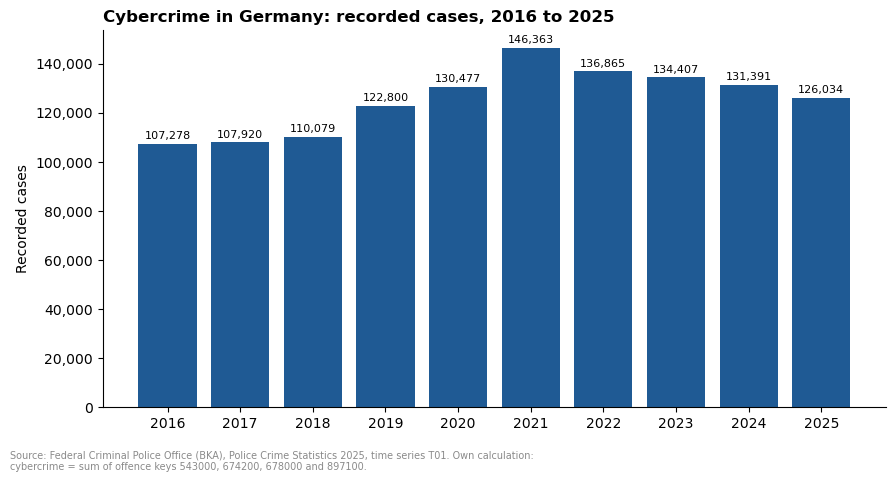

In [11]:
SOURCE = ("Source: Federal Criminal Police Office (BKA), Police Crime Statistics 2025, time series T01. "
          "Own calculation:\ncybercrime = sum of offence keys 543000, 674200, 678000 and 897100.")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(federal_cyber.index, federal_cyber["cases"], color=BLUE)
for year, value in federal_cyber["cases"].items():
    ax.text(year, value + 2000, f"{value:,.0f}", ha="center", fontsize=8)
ax.set_title("Cybercrime in Germany: recorded cases, 2016 to 2025", loc="left", fontweight="bold")
ax.set_ylabel("Recorded cases")
ax.set_xticks(federal_cyber.index)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
fig.text(0.01, 0.01, SOURCE, fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "01_cybercrime_cases.png", dpi=150)
plt.show()

Recorded cybercrime rose from 107,278 cases in 2016 to a peak of 146,363 in 2021 (+36.4 %) and has fallen in every year since. In 2025 the police recorded 126,034 cases, 13.9 % below the peak and 17.5 % above 2016.

All recorded crime moved the other way: it fell by 13.6 % between 2016 and 2025. The share of cybercrime in all recorded crime therefore grew from 1.7 % to 2.3 %, with a peak of 2.9 % in 2021.

**What the BKA says about the development.** The PKS shows the development, not its causes. The BKA comments on them in its situation reports:

- **Rise until 2021.** The BKA links it to the further accelerated digitalisation, driven among other things by the COVID-19 pandemic, which creates many new opportunities for cybercriminals ([BKA press release, 9 May 2022](https://www.presseportal.de/blaulicht/pm/7/5217298)).
- **Decline in 2022.** The BKA explains it with the easing of the pandemic measures: online shopping and remote work had offered additional opportunities for attacks in the years before, and in 2022 part of the crime moved back into the analogue world ([Bundeslagebild Cybercrime 2022](https://www.bka.de/SharedDocs/Downloads/DE/Publikationen/JahresberichteUndLagebilder/Cybercrime/cybercrimeBundeslagebild2022.pdf?__blob=publicationFile&v=4), page 7).
- **Russia's war against Ukraine.** The war began on 24 February 2022. The BKA writes that it led to a heightened cyber threat situation in Germany as well (Bundeslagebild 2022, page 22). The cases recorded in the PKS nevertheless fell in 2022.
- **Offences committed from abroad.** The BKA calls the decline in 2022 an apparent one. Offences that cause damage in Germany while the offender is abroad or at an unknown location have been recorded separately since 2020. They rose by more than 8 % in 2022, while the cases recorded in Germany fell by 6.5 % (Bundeslagebild 2022, page 6). These offences are not part of the figures used here (Section 11).

## 8. Question 2: Clearance Rate of Cybercrime vs. All Recorded Crime

The clearance rate is the number of cleared cases as a share of the recorded cases of the same year.

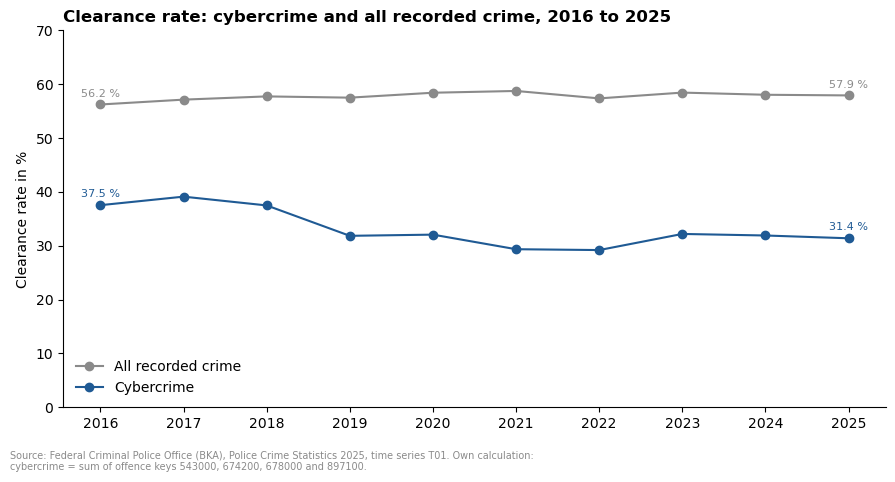

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(federal_cyber.index, federal_cyber["clearance_rate_all_crime"], color=MUTED, marker="o",
        label="All recorded crime")
ax.plot(federal_cyber.index, federal_cyber["clearance_rate"], color=BLUE, marker="o", label="Cybercrime")

# Label the first and last year of both lines
for column, color in [("clearance_rate_all_crime", MUTED), ("clearance_rate", BLUE)]:
    for year in (FIRST_YEAR, LAST_YEAR):
        value = federal_cyber.loc[year, column]
        ax.text(year, value + 1.5, f"{value:.1f} %", ha="center", fontsize=8, color=color)

ax.set_title("Clearance rate: cybercrime and all recorded crime, 2016 to 2025", loc="left", fontweight="bold")
ax.set_ylabel("Clearance rate in %")
ax.set_ylim(0, 70)
ax.set_xticks(federal_cyber.index)
ax.legend(frameon=False, loc="lower left")
fig.text(0.01, 0.01, SOURCE, fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "02_clearance_rate.png", dpi=150)
plt.show()

The clearance rate of cybercrime is far below the rate of all recorded crime in every year, and the gap has widened. In 2016 the police cleared 37.5 % of the cybercrime cases, in 2025 31.4 %. The rate of all recorded crime stayed between 56 % and 59 % over the whole period. The gap grew from 18.7 percentage points in 2016 to 26.5 in 2025.

The drop happened in one step: the cybercrime rate fell from 37.5 % in 2018 to 31.8 % in 2019 and has stayed at about 29 % to 32 % since. The lowest value is 29.2 % in 2022.

The number of cleared cases hardly changed: between about 39,100 and 43,200 in every year. Over the same period the number of recorded cases grew.

## 9. Question 3: Cybercrime in the Federal States, 2025 and 2016

The comparison uses cases per 100,000 inhabitants, so states of different size can be compared. Two points in time are shown: 2025 as the main comparison, and 2016 to see whether a state is high permanently or only in one year.

- **2025:** key 897000 is used directly, because it equals the sum of the four offence keys since 2021. The BKA table already contains the cases per 100,000 inhabitants.
- **2016:** the four offence keys are summed per state (today's definition, Section 6). The rate has to be recalculated for this sum. The population of each state is derived from the row of all recorded crime in the same file (cases divided by rate), so every year uses its own population figure.

In [13]:
# --- 2016: sum of the four offence keys per state ---
s16 = states_2016[states_2016["state"] != TOTAL_ROW_2016]

# Population 2016 per state, derived from the row "all recorded crime"
all_2016 = s16[s16["key"] == KEY_ALL_CRIME].set_index("state")
population_2016 = all_2016["cases"] / all_2016["rate"] * 100_000

cyber_2016 = s16[s16["key"].isin(CYBER_PARTS)].groupby("state")[["cases", "cleared"]].sum()
cyber_2016["rate"] = cyber_2016["cases"] / population_2016 * 100_000
cyber_2016["clearance_rate"] = 100 * cyber_2016["cleared"] / cyber_2016["cases"]

# --- 2025: aggregate key 897000 as published ---
s25 = states_2025[states_2025["state"] != TOTAL_ROW_2025]
cyber_2025 = s25[s25["key"] == KEY_CYBER].set_index("state")[["cases", "cleared", "rate", "clearance_rate"]]

# --- Combine both years ---
states = cyber_2016.add_suffix("_2016").join(cyber_2025.add_suffix("_2025"))
states = states.rename(index=STATE_NAMES_EN)        # English state names for tables and charts
states["rate_change_pct"] = 100 * (states["rate_2025"] / states["rate_2016"] - 1)
states["rank_2016"] = states["rate_2016"].rank(ascending=False).astype(int)
states["rank_2025"] = states["rate_2025"].rank(ascending=False).astype(int)
states = states.sort_values("rate_2025", ascending=False)

# Check: the state totals must equal the federal figures of Section 7
print("Sum of cases 2016:", cyber_2016["cases"].sum(), "| federal:", federal_cyber.loc[2016, "cases"])
print("Sum of cases 2025:", cyber_2025["cases"].sum(), "| federal:", federal_cyber.loc[2025, "cases"])
print("Population 2016 (derived):", f"{population_2016.sum():,.0f}")

states.round(1)

Sum of cases 2016: 107278 | federal: 107278
Sum of cases 2025: 126034 | federal: 126034
Population 2016 (derived): 82,175,684


,cases_2016,cleared_2016,rate_2016,clearance_rate_2016,cases_2025,cleared_2025,rate_2025,clearance_rate_2025,rate_change_pct,rank_2016,rank_2025
state,,,,,,,,,,,
Bremen,1860,509,277.0,27.4,3969,521,563.1,13.1,103.3,2,1
Berlin,22384,4544,635.9,20.3,18341,3835,497.7,20.9,-21.7,1,2
Hamburg,3629,915,203.0,25.2,6454,594,346.5,9.2,70.7,3,3
Hesse,7103,4302,115.0,60.6,13207,4229,210.3,32.0,82.8,10,4
Lower Saxony,8234,4506,103.9,54.7,13392,5385,167.3,40.2,61.1,11,5
Schleswig-Holstein,2103,1090,73.6,51.8,4183,986,141.3,23.6,92.1,14,6
Thuringia,2716,965,125.1,35.5,2925,794,139.3,27.1,11.3,8,7
Saxony-Anhalt,2902,1437,129.2,49.5,2720,1233,127.4,45.3,-1.4,6,8
North Rhine-Westphalia,22657,7253,126.8,32.0,22076,7419,122.4,33.6,-3.5,7,9


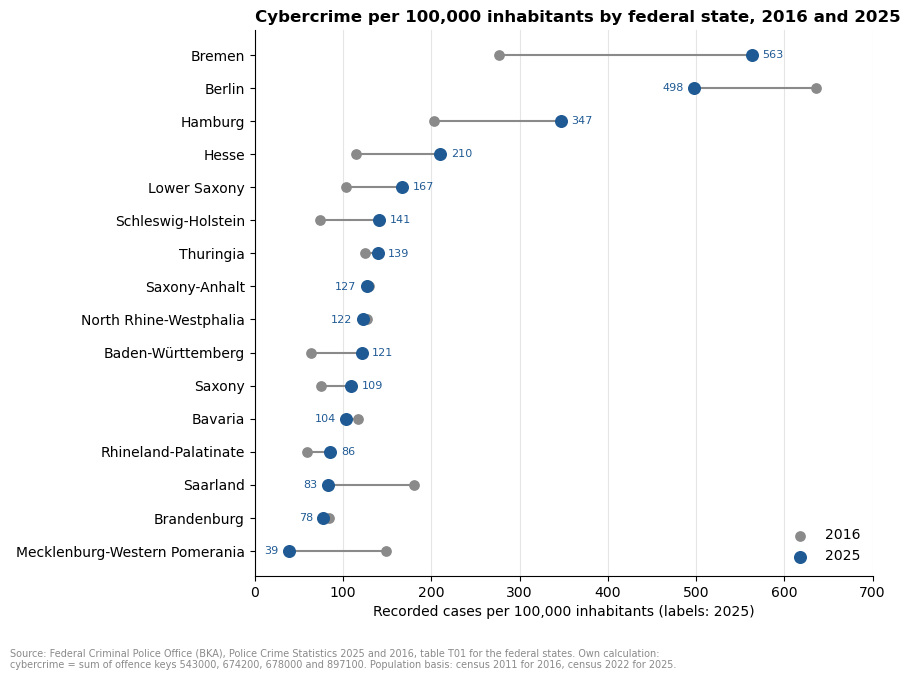

In [14]:
SOURCE_STATES = ("Source: Federal Criminal Police Office (BKA), Police Crime Statistics 2025 and 2016, table T01 for the "
                 "federal states. Own calculation:\ncybercrime = sum of offence keys 543000, 674200, 678000 and 897100. "
                 "Population basis: census 2011 for 2016, census 2022 for 2025.")

ranking = states.sort_values("rate_2025")      # smallest value at the bottom of the chart
y = range(len(ranking))

fig, ax = plt.subplots(figsize=(9, 6.8))
# One line per state from the 2016 value to the 2025 value
ax.hlines(y, ranking["rate_2016"], ranking["rate_2025"], color=MUTED, linewidth=1.5, zorder=1)
ax.scatter(ranking["rate_2016"], y, color=MUTED, s=45, zorder=2, label="2016")
ax.scatter(ranking["rate_2025"], y, color=BLUE, s=70, zorder=3, label="2025")
# The label belongs to the 2025 point: right of it after a rise, left of it after a fall
for i, (old, new) in enumerate(zip(ranking["rate_2016"], ranking["rate_2025"])):
    if new >= old:
        ax.text(new + 12, i, f"{new:.0f}", va="center", ha="left", fontsize=8, color=BLUE)
    else:
        ax.text(new - 12, i, f"{new:.0f}", va="center", ha="right", fontsize=8, color=BLUE)

ax.set_xlim(0, 700)
ax.grid(axis="x", color="#e5e5e5", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_yticks(y)
ax.set_yticklabels(ranking.index)
ax.set_title("Cybercrime per 100,000 inhabitants by federal state, 2016 and 2025", loc="left", fontweight="bold")
ax.set_xlabel("Recorded cases per 100,000 inhabitants (labels: 2025)")
ax.legend(frameon=False, loc="lower right")
fig.text(0.01, 0.01, SOURCE_STATES, fontsize=7, color=MUTED)
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "03_federal_states.png", dpi=150)
plt.show()

The differences between the federal states are very large. In 2025 Bremen recorded 563 cybercrime cases per 100,000 inhabitants and Mecklenburg-Western Pomerania 39, a factor of 14.5. The national figure is 151.

**The three city states lead in both years.** Berlin, Bremen and Hamburg hold ranks 1 to 3 in 2016 and in 2025. Their high level is therefore not an outlier of a single year.

**Below the city states the ranking is not stable.** The rate rose in nine states and fell in seven. It roughly doubled in Bremen (+103 %) and grew by 83 % to 92 % in Hesse, Baden-Württemberg and Schleswig-Holstein. It fell by 74 % in Mecklenburg-Western Pomerania (from rank 5 to rank 16) and by 54 % in Saarland (from rank 4 to rank 14).

**The three states with the highest rates have the lowest clearance rates.** In 2025 these are Hamburg (9.2 %), Bremen (13.1 %) and Berlin (20.9 %). Brandenburg has the highest clearance rate (59.0 %).

The tables do not show why the states differ this much, and the BKA notes on the PKS 2025 list no special circumstance for any state in this field. In general the BKA points out that high rates of increase are partly due to investigation complexes with numerous individual cases (note in the table PKS 2016, T01 Fallentwicklung). Whether this applies to a particular state does not follow from the tables.

### Why Is Bremen So High?

Bremen stands out even among the three city states. The next cell looks into the computer fraud of the three city states and compares one of its offence keys: 516920, computer fraud with unlawfully obtained other non-cash means of payment (means of payment other than payment cards).

In [15]:
KEY_OTHER_PAYMENT = "516920"   # computer fraud with unlawfully obtained other non-cash means of payment
compare = ["Bremen", "Berlin", "Hamburg", "Germany"]

def key_by_state(df, total_row):
    # Cases and rate of one offence key for the three city states and Germany as a whole
    rows = df[df["key"] == KEY_OTHER_PAYMENT].set_index("state").rename(index={total_row: "Germany"})
    return rows.loc[compare, ["cases", "rate", "clearance_rate"]]

other_payment = key_by_state(states_2016, TOTAL_ROW_2016).add_suffix("_2016").join(
    key_by_state(states_2025, TOTAL_ROW_2025).add_suffix("_2025"))

# Bremen's cybercrime rate in 2025 without this one key
bremen_without = states.loc["Bremen", "rate_2025"] - other_payment.loc["Bremen", "rate_2025"]
share_of_germany = 100 * other_payment.loc["Bremen", "cases_2025"] / other_payment.loc["Germany", "cases_2025"]
print(f"Bremen 2025 without key {KEY_OTHER_PAYMENT}: {bremen_without:.0f} cases per 100,000 inhabitants")
print(f"Bremen's share of all cases of this key in Germany: {share_of_germany:.1f} %")

other_payment.round(1)

Bremen 2025 without key 516920: 306 cases per 100,000 inhabitants
Bremen's share of all cases of this key in Germany: 14.3 %


,cases_2016,rate_2016,clearance_rate_2016,cases_2025,rate_2025,clearance_rate_2025
state,,,,,,
Bremen,71,10.6,25.4,1809,256.6,7.7
Berlin,103,2.9,35.0,392,10.6,20.9
Hamburg,24,1.3,20.8,199,10.7,15.6
Germany,1906,2.3,33.6,12628,15.1,23.4


Almost half of Bremen's value comes from this one offence key. In 2025 Bremen recorded 1,809 such cases or 257 per 100,000 inhabitants, 17 times the national rate of 15. Berlin and Hamburg are at 11. Bremen has 0.8 % of the German population but 14.3 % of all cases of this key. In 2016 Bremen recorded 11 cases per 100,000 inhabitants under this key.

Without this key Bremen would be at about 306 cases per 100,000 inhabitants in 2025, below Hamburg (347) and Berlin (498). Only 7.7 % of these cases were cleared in Bremen, compared with 13.1 % for all cybercrime in the state.

Why this key is so high in Bremen in particular does not follow from the PKS tables. The rise is not new: for 2022 the Weser-Kurier reported that computer fraud with stolen non-cash means of payment in Bremen had more than doubled within one year, from 968 to 2,136 cases. According to the report, the Bremen State Criminal Police Office sees this rise favoured by the growing use of electronic payment methods such as Apple Pay and Google Pay on mobile devices ([Weser-Kurier, 6 March 2023](https://www.weser-kurier.de/bremen/politik/bremer-kriminalstatistik-immer-mehr-digitale-straftaten-doc7p7nodmh7tg1b8franvb)).

## 10. Save the Clean Tables

The two result tables are saved for the dashboard. The column names are documented below.

| File | Rows | Columns |
|---|---|---|
| `cybercrime_federal.csv` | One per year, 2016 to 2025 | `cases`, `cleared`, `clearance_rate` (cybercrime); `cases_all_crime`, `clearance_rate_all_crime`; `share_of_all_crime_pct` |
| `cybercrime_states.csv` | One per federal state | `cases`, `cleared`, `rate`, `clearance_rate` for 2016 and 2025; `rate_change_pct`; `rank_2016`, `rank_2025` |

In [16]:
federal_cyber.to_csv(DATA_CLEAN / "cybercrime_federal.csv")
states.to_csv(DATA_CLEAN / "cybercrime_states.csv")

print("Saved to data/clean:", sorted(p.name for p in DATA_CLEAN.glob("cybercrime_*.csv")))
print("Saved to figures:   ", sorted(p.name for p in FIGURES.glob("0*.png")))

Saved to data/clean: ['cybercrime_federal.csv', 'cybercrime_states.csv']
Saved to figures:    ['01_cybercrime_cases.png', '02_clearance_rate.png', '03_federal_states.png']


## 11. Limitations

**The PKS shows recorded crime, not all crime.** It counts only cases that became known to the police. According to the BKA, studies estimate the unreported share of cybercrime at up to 91.5 %. The BKA therefore writes that the PKS has only limited informative value for the cyber offences actually committed and is suited mainly for statements on the trend ([Bundeslagebild Cybercrime 2022](https://www.bka.de/SharedDocs/Downloads/DE/Publikationen/JahresberichteUndLagebilder/Cybercrime/cybercrimeBundeslagebild2022.pdf?__blob=publicationFile&v=4), page 4).

**Only offences committed in Germany are included.** Since 2014 a cybercrime case is counted in the PKS only when there are concrete indications that the act was carried out in Germany (BKA notes on the time series, page 19). Offences committed from abroad, or from an unknown location, against victims in Germany are not part of these figures. The BKA has recorded them separately since 2020; they are not analysed here. They rose by more than 8 % in 2022 while the cases recorded in Germany fell (Bundeslagebild 2022, page 6).

**The definition is narrow.** Key 897000 covers four offences, and more than 80 % of the cases are computer fraud. Offences committed with the internet as a tool are published by the BKA in a separate table (T05, "Tatmittel Internet") and are not analysed here.

**The definition changed in 2021.** Until 2020 the published key 897000 contained software piracy. This was corrected by using the sum of the four offence keys in all years (Section 6).

**The clearance rate before 2019 is an approximation.** The federal time series gives the clearance rate only in percent, until 2018 with one decimal place. The cleared cases calculated from it are therefore rounded. In addition, cases cleared in one year can have been recorded in an earlier year, as the BKA notes in its tables (PKS 2016, T01 Fallentwicklung), so the rate is not the share of a fixed set of cases.

**The population basis changed.** Rates for 2016 are based on the census of 2011, rates for 2025 on the census of 2022. According to the BKA, rates from 2024 on are comparable with earlier years only to a limited extent. The population of 2016 was not taken from a population table but derived from cases and rate in the BKA file.

**The state comparison has two points in time.** It shows where each state stood in 2016 and in 2025, not the path in between. The tables do not show where the large differences between the states come from (Section 9).

## 12. Summary and Key Findings

- **Recorded cybercrime peaked in 2021 and has fallen since.** Cases rose from **107,278** in 2016 to **146,363** in 2021 and fell to **126,034** in 2025. That is **13.9 %** below the peak and **17.5 %** above 2016.
- **Cybercrime gained weight in the statistics.** All recorded crime fell by **13.6 %** in the same period, so the share of cybercrime grew from **1.7 %** to **2.3 %**.
- **Fewer than one in three cases is cleared.** The clearance rate fell from **37.5 %** in 2016 to **31.4 %** in 2025, while the rate of all recorded crime stayed between **56 %** and **59 %**. The gap grew from **18.7** to **26.5** percentage points.
- **The federal states differ by a factor of 14.5.** In 2025 Bremen recorded **563** cases per 100,000 inhabitants, Mecklenburg-Western Pomerania **39**. The three city states Berlin, Bremen and Hamburg hold ranks 1 to 3 in both 2016 and 2025.
- **The states with the most cases clear the fewest.** The three states with the highest rates have the three lowest clearance rates in 2025: Hamburg **9.2 %**, Bremen **13.1 %** and Berlin **20.9 %**. Brandenburg has the highest clearance rate with **59.0 %**.
- **The states also developed very differently.** Rates changed between **−74 %** and **+103 %** from 2016 to 2025. The tables do not show where these differences come from.
- **Bremen's top position comes from one offence key.** Computer fraud with unlawfully obtained other non-cash means of payment (key 516920) accounts for **257** of Bremen's **563** cases per 100,000 inhabitants, **17 times** the national rate. Without it Bremen would be below Hamburg and Berlin.
- **The peak in 2021 falls into the pandemic.** The BKA links the rise to the accelerated digitalisation during the COVID-19 pandemic and the decline in 2022 to the easing of the pandemic measures. The data itself does not show the cause.
- **Cybercrime in the BKA definition is mostly computer fraud:** **82.3 %** of the cases in 2025. The figures cover only offences committed in Germany and reported to the police.

## 13. Data Sources

All data is published by the Federal Criminal Police Office (Bundeskriminalamt, BKA), Wiesbaden, as part of the Police Crime Statistics (Polizeiliche Kriminalstatistik, PKS). The BKA allows reproduction only with attribution to the Bundeskriminalamt. All figures on cybercrime before 2021, all clearance rates before 2021 and the rates per 100,000 inhabitants for 2016 are own calculations based on these tables.

**Tables**

| Used for | Table | File in `data/raw` | Version |
|---|---|---|---|
| Sections 6 to 8 | PKS 2025, time series, T01 Grundtabelle – Fälle ab 1987 | `T01-ZR-Bund-Fälle_xls.xlsx` | V1.1, 8 April 2026 |
| Section 9 (2025) | PKS 2025, T01 Grundtabelle – Fälle mit Häufigkeitszahl (HZ) – Länder | `LA-F-02-T01-Laender-Faelle-HZ_xls.xlsx` | V1.0, 6 March 2026 |
| Section 9 (2016) | PKS 2016, T01 Grundtabelle – Länder | `BKA-LKS-F-01-T01-Laender_excel.xlsx` | 27 January 2017 |
| Notes of the BKA only, no calculations (Sections 6, 9 and 11) | PKS 2016, T01 Grundtabelle – Länder – Fallentwicklung | `BKA-LKS-F-02-T0-Laender-Fallentwicklung_excel.xlsx` | 1 February 2017 |

**Documents**

| Used for | Document | Version |
|---|---|---|
| Definition of cybercrime (Section 6) | PKS 2025 – Übersicht Summenschlüssel, page 9 | V1.0 |
| Recording rule since 2014, new key in 2016, change of the definition in 2021 (Sections 6 and 11) | PKS 2025 – Hinweise zu den Zeitreihen, pages 19, 23 and 40 | V1.0 |
| Population basis and special circumstances of the states in 2025 (Sections 9 and 11) | PKS 2025 – Wichtige Hinweise zur Interpretation der Daten, pages 4 to 6 | V1.0 |

**Further sources for context (not used for calculations)**

| Used for | Source |
|---|---|
| Rise until 2021 (Section 7) | BKA, press release on the Bundeslagebild Cybercrime 2021, 9 May 2022: https://www.presseportal.de/blaulicht/pm/7/5217298 |
| Decline in 2022, war in Ukraine, offences committed from abroad, unreported cases, figures for 2020 to 2022 (Sections 6, 7 and 11) | BKA, Bundeslagebild Cybercrime 2022, pages 4 to 7 and 22: https://www.bka.de/SharedDocs/Downloads/DE/Publikationen/JahresberichteUndLagebilder/Cybercrime/cybercrimeBundeslagebild2022.pdf?__blob=publicationFile&v=4 |
| Computer fraud in Bremen in 2022 (Section 9) | Frank Hethey, "Immer mehr digitale Straftaten in Bremen", Weser-Kurier, 6 March 2023: https://www.weser-kurier.de/bremen/politik/bremer-kriminalstatistik-immer-mehr-digitale-straftaten-doc7p7nodmh7tg1b8franvb |

**Where to find the data**

- PKS 2025, tables and notes: https://www.bka.de/DE/AktuelleInformationen/StatistikenLagebilder/PolizeilicheKriminalstatistik/PKS2025/pksTabellen_Interpretationshilfen/pksTabellen_Interpretationshilfen_node.html
- PKS 2025, time series: https://www.bka.de/DE/AktuelleInformationen/StatistikenLagebilder/PolizeilicheKriminalstatistik/PKS2025/pksTabellen_Interpretationshilfen/Zeitreihen/zeitreihen_node.html
- PKS, all reporting years (including 2016): https://www.bka.de/DE/AktuelleInformationen/StatistikenLagebilder/PolizeilicheKriminalstatistik/pks_node.html